In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from db.database import Database
from util.dataframe_utils import get_dataframes
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity

In [2]:
db = Database()
bp_df, topics_df, posts_df = get_dataframes(db)
bp_df.head()

,blueprint_code,blueprint_url,post_id,description,topic_keywords,keywords_tfidf,blueprint_hash,id,name,extracted_keywords,keywords_yake,topic_title,topic_id,tags,created_at,post_content,processed_keywords
0,blueprint:\n name: Nag prompt blueprint\n de...,https://community.home-assistant.io//t/nag-pro...,1220860,Nag a mobile device to do something,"{""nag"": 0.66021433671546, ""prompt"": 0.23634566...","{""nag"": 0.8500419399246807, ""prompt"": 0.303868...",2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,1,Nag prompt blueprint,"{""input__input_boolean"": 2}","[""android notification"", ""nag prompt"", ""nag no...",Nag prompt Blueprint (Android Notification),255041,[],2020-12-14 01:40:32.358,<p>This blueprints creates configurable nag no...,"[""boolean""]"
1,blueprint:\n name: Inovelli \n description: ...,https://community.home-assistant.io//t/inovell...,1220678,Use this blueprint to create automations based...,"{""inovelli"": 0.49695533075954657, ""lzw36"": 0.4...","{""lzw36"": 0.44023949481589464, ""inovelli"": 0.4...",ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,2,Inovelli,{},"[""fan"", ""inovelli"", ""create"", ""dimmer""]",Inovelli LZW36 Fan/Dimmer Scenes,254999,"[""blueprint""]",2020-12-13 22:32:38.158,<p>This blueprint allows you to easily create ...,null
2,blueprint:\n name: deCONZ - IKEA five button ...,https://community.home-assistant.io//t/deconz-...,1223455,Control anything using IKEA five button remote\n,"{""button"": 0.47028047688169866, ""five"": 0.3549...","{""five"": 0.5604759426620674, ""ikea"": 0.4331904...",c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,3,deCONZ - IKEA five button remote,"{""input__deconz"": 1}","[""button short"", ""button remote"", ""long press""...",deCONZ - IKEA five button remote,255699,"[""switch"", ""blueprint"", ""deconz""]",2020-12-15 12:18:15.898,"<p>This is a mix of <a href=""https://community...","[""deconz""]"
3,blueprint:\n name: Heat for certain time\n d...,https://community.home-assistant.io//t/set-hea...,1223628,Turn on heating for a given amount of time.,"{""heat"": 0.3484675281776271, ""heating"": 0.3360...","{""heat"": 0.44290156715634094, ""heating"": 0.430...",00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,4,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}","[""set heating"", ""heating temperature"", ""time"",...",Set heating temperature to a configurable valu...,255742,[],2020-12-15 14:23:53.414,"<p>This is a blueprint, that allows to set the...","[""datetime"", ""climate""]"
4,blueprint:\n name: Light Allowance\n descrip...,https://community.home-assistant.io//t/light-a...,1224871,Turns a light off after an allotted time,"{""allotted"": 0.6330710810698282, ""allowance"": ...","{""allotted"": 0.6465282359948884, ""allowance"": ...",0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,5,Light Allowance,"{""input__light"": 1, ""output__light"": 1}","[""light allowance"", ""light"", ""allowance"", ""all...",Light Allowance,256045,[],2020-12-16 04:23:36.519,<p>This blueprint will turn a light off after ...,"[""light"", ""light""]"


In [3]:
import json, re
def process_bp_keywords(kwd_dict: dict[str, int] | str) -> list[str] | None:
    if isinstance(kwd_dict, str):
        kwd_dict = json.loads(kwd_dict)
    
    kwd_list = list(kwd_dict.keys())
    if kwd_list.__len__() < 1:
        return None
    
    kwds = []
    
    for kwd in kwd_list:
        in_out = re.search(r"(input__|output__)(input_|output_)?", kwd)
        kwd = kwd.removeprefix(in_out.group()) if in_out else kwd
        in_out = in_out.group(1) if in_out else None
        kwds.append(in_out + kwd if in_out else kwd)
    return kwds

In [4]:
ignorable_tags = {"blueprint", "automation"}
bp_df["tags"] = bp_df["tags"].apply(lambda tags: [tag for tag in json.loads(tags) if tag not in ignorable_tags])
bp_df.head()

,blueprint_code,blueprint_url,post_id,description,topic_keywords,keywords_tfidf,blueprint_hash,id,name,extracted_keywords,keywords_yake,topic_title,topic_id,tags,created_at,post_content,processed_keywords
0,blueprint:\n name: Nag prompt blueprint\n de...,https://community.home-assistant.io//t/nag-pro...,1220860,Nag a mobile device to do something,"{""nag"": 0.66021433671546, ""prompt"": 0.23634566...","{""nag"": 0.8500419399246807, ""prompt"": 0.303868...",2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,1,Nag prompt blueprint,"{""input__input_boolean"": 2}","[""android notification"", ""nag prompt"", ""nag no...",Nag prompt Blueprint (Android Notification),255041,[],2020-12-14 01:40:32.358,<p>This blueprints creates configurable nag no...,"[""boolean""]"
1,blueprint:\n name: Inovelli \n description: ...,https://community.home-assistant.io//t/inovell...,1220678,Use this blueprint to create automations based...,"{""inovelli"": 0.49695533075954657, ""lzw36"": 0.4...","{""lzw36"": 0.44023949481589464, ""inovelli"": 0.4...",ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,2,Inovelli,{},"[""fan"", ""inovelli"", ""create"", ""dimmer""]",Inovelli LZW36 Fan/Dimmer Scenes,254999,[],2020-12-13 22:32:38.158,<p>This blueprint allows you to easily create ...,null
2,blueprint:\n name: deCONZ - IKEA five button ...,https://community.home-assistant.io//t/deconz-...,1223455,Control anything using IKEA five button remote\n,"{""button"": 0.47028047688169866, ""five"": 0.3549...","{""five"": 0.5604759426620674, ""ikea"": 0.4331904...",c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,3,deCONZ - IKEA five button remote,"{""input__deconz"": 1}","[""button short"", ""button remote"", ""long press""...",deCONZ - IKEA five button remote,255699,"[switch, deconz]",2020-12-15 12:18:15.898,"<p>This is a mix of <a href=""https://community...","[""deconz""]"
3,blueprint:\n name: Heat for certain time\n d...,https://community.home-assistant.io//t/set-hea...,1223628,Turn on heating for a given amount of time.,"{""heat"": 0.3484675281776271, ""heating"": 0.3360...","{""heat"": 0.44290156715634094, ""heating"": 0.430...",00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,4,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}","[""set heating"", ""heating temperature"", ""time"",...",Set heating temperature to a configurable valu...,255742,[],2020-12-15 14:23:53.414,"<p>This is a blueprint, that allows to set the...","[""datetime"", ""climate""]"
4,blueprint:\n name: Light Allowance\n descrip...,https://community.home-assistant.io//t/light-a...,1224871,Turns a light off after an allotted time,"{""allotted"": 0.6330710810698282, ""allowance"": ...","{""allotted"": 0.6465282359948884, ""allowance"": ...",0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,5,Light Allowance,"{""input__light"": 1, ""output__light"": 1}","[""light allowance"", ""light"", ""allowance"", ""all...",Light Allowance,256045,[],2020-12-16 04:23:36.519,<p>This blueprint will turn a light off after ...,"[""light"", ""light""]"


In [5]:
max_keywords = bp_df["extracted_keywords"].apply(lambda x: len(json.loads(x)) if isinstance(x, str) else 0).max() 
max_tags = bp_df["tags"].apply(lambda x: len(x) if isinstance(x, list) else 0).max()
max_yake = 4
max_features = max_keywords + max_tags + max_yake
max_keywords, max_tags, max_features

(13, 5, 22)

In [6]:
def extract_features(row, max_features=max_features):
    padding = "<PAD>"
    
    yake_features = json.loads(row["keywords_yake"])
    combined_features = list(yake_features)
    ext_kw = process_bp_keywords(row["extracted_keywords"])
    if ext_kw:
        combined_features.extend(ext_kw)
    
    kw_n = max_keywords - len(ext_kw) if ext_kw else max_keywords
    combined_features += [padding] * kw_n
    
    tags = row["tags"]
    tag_n = max_tags - len(tags)
    combined_features.extend(tags)
    combined_features += [padding] * tag_n

    return combined_features

In [7]:
bp_df["features"] = bp_df.apply(extract_features, axis=1)
bp_df.head()

,blueprint_code,blueprint_url,post_id,description,topic_keywords,keywords_tfidf,blueprint_hash,id,name,extracted_keywords,keywords_yake,topic_title,topic_id,tags,created_at,post_content,processed_keywords,features
0,blueprint:\n name: Nag prompt blueprint\n de...,https://community.home-assistant.io//t/nag-pro...,1220860,Nag a mobile device to do something,"{""nag"": 0.66021433671546, ""prompt"": 0.23634566...","{""nag"": 0.8500419399246807, ""prompt"": 0.303868...",2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,1,Nag prompt blueprint,"{""input__input_boolean"": 2}","[""android notification"", ""nag prompt"", ""nag no...",Nag prompt Blueprint (Android Notification),255041,[],2020-12-14 01:40:32.358,<p>This blueprints creates configurable nag no...,"[""boolean""]","[android notification, nag prompt, nag notific..."
1,blueprint:\n name: Inovelli \n description: ...,https://community.home-assistant.io//t/inovell...,1220678,Use this blueprint to create automations based...,"{""inovelli"": 0.49695533075954657, ""lzw36"": 0.4...","{""lzw36"": 0.44023949481589464, ""inovelli"": 0.4...",ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,2,Inovelli,{},"[""fan"", ""inovelli"", ""create"", ""dimmer""]",Inovelli LZW36 Fan/Dimmer Scenes,254999,[],2020-12-13 22:32:38.158,<p>This blueprint allows you to easily create ...,null,"[fan, inovelli, create, dimmer, <PAD>, <PAD>, ..."
2,blueprint:\n name: deCONZ - IKEA five button ...,https://community.home-assistant.io//t/deconz-...,1223455,Control anything using IKEA five button remote\n,"{""button"": 0.47028047688169866, ""five"": 0.3549...","{""five"": 0.5604759426620674, ""ikea"": 0.4331904...",c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,3,deCONZ - IKEA five button remote,"{""input__deconz"": 1}","[""button short"", ""button remote"", ""long press""...",deCONZ - IKEA five button remote,255699,"[switch, deconz]",2020-12-15 12:18:15.898,"<p>This is a mix of <a href=""https://community...","[""deconz""]","[button short, button remote, long press, butt..."
3,blueprint:\n name: Heat for certain time\n d...,https://community.home-assistant.io//t/set-hea...,1223628,Turn on heating for a given amount of time.,"{""heat"": 0.3484675281776271, ""heating"": 0.3360...","{""heat"": 0.44290156715634094, ""heating"": 0.430...",00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,4,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}","[""set heating"", ""heating temperature"", ""time"",...",Set heating temperature to a configurable valu...,255742,[],2020-12-15 14:23:53.414,"<p>This is a blueprint, that allows to set the...","[""datetime"", ""climate""]","[set heating, heating temperature, time, set, ..."
4,blueprint:\n name: Light Allowance\n descrip...,https://community.home-assistant.io//t/light-a...,1224871,Turns a light off after an allotted time,"{""allotted"": 0.6330710810698282, ""allowance"": ...","{""allotted"": 0.6465282359948884, ""allowance"": ...",0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,5,Light Allowance,"{""input__light"": 1, ""output__light"": 1}","[""light allowance"", ""light"", ""allowance"", ""all...",Light Allowance,256045,[],2020-12-16 04:23:36.519,<p>This blueprint will turn a light off after ...,"[""light"", ""light""]","[light allowance, light, allowance, allotted, ..."


In [8]:
from sklearn.preprocessing import normalize
model = SentenceTransformer('all-MiniLM-L6-v2')

# Apply the updated function
bp_df["features"] = bp_df.apply(lambda row: extract_features(row, max_features=15), axis=1)

bp_df["features"] = bp_df["features"].apply(lambda x: " ".join(x))  # Combine list of strings into a single string
bp_df["embeddings"] = bp_df["features"].apply(lambda x: model.encode(x))

# Create a feature matrix
X = np.vstack(bp_df["embeddings"].values)
X_normalized = normalize(X, norm='l2')

In [ ]:
from collections import Counter

def analyze_cluster_features(bp_df, cluster_id, top_n=10):
    """Analyze the most common features in a specific cluster"""
    cluster_data = bp_df[bp_df["top_cluster"] == cluster_id]
    
    all_features = []
    for features in cluster_data["features"]:
        feature_list = [f for f in features.split() if f != "<PAD>"]
        all_features.extend(feature_list)
    
    feature_counts = Counter(all_features)
    
    """ print(f"\nTop {top_n} features in Cluster {cluster_id}:")
    for feature, count in feature_counts.most_common(top_n):
        print(f"  {feature}: {count}") """
    
    return feature_counts.most_common(top_n)

### Two-stage KMeans (top-down)

In [9]:
k_top = 15
kmeans_top = KMeans(n_clusters=k_top, random_state=42)
bp_df["top_cluster"] = kmeans_top.fit_predict(X_normalized)

In [10]:
bp_df["sub_cluster"] = -1

for c in range(k_top):
    mask = bp_df["top_cluster"] == c
    X_sub = X_normalized[mask]
    
    if len(X_sub) < 10:
        continue
    
    k_sub = min(5, len(X_sub) // 5)
    km = KMeans(n_clusters=k_sub, random_state=42)

    bp_df.loc[mask, "sub_cluster"] = km.fit_predict(X_sub)

In [12]:
def write_to_md(filename: str):    
    with open(filename, "w", encoding="utf-8") as f:
        for cluster_id in range(kmeans_top.n_clusters):
            f.write(f"<details>\n")
            features = analyze_cluster_features(bp_df, cluster_id, top_n=5)
            f.write(f"<summary> Cluster {cluster_id} </summary>\n\n")
            f.write(f"Top 5 features: \n")
            for feature, count in features:
                f.write(f"- {feature}: {count} \n")
            f.write("\n")
            sub_clusters = bp_df[bp_df["top_cluster"] == cluster_id]["sub_cluster"].unique()
            f.write(f"Sub-clusters: {', '.join(map(str, sub_clusters))} \n\n")
            for sub_cluster in sub_clusters:
                bps = bp_df[(bp_df["top_cluster"] == cluster_id) & (bp_df["sub_cluster"] == sub_cluster)]
                f.write(f"### Sub-cluster {sub_cluster}\n\n")
                for idx, bp in bps.iterrows():
                    post_url = topics_df[topics_df["post_id"] == bp["post_id"]]["post_url"].values[0]
                    f.write(f"- {bp['name']}, [Link]({post_url}) \n")
                f.write("\n")
c_name = "hierarchical_clusters_norm_15_5"
write_to_md(f"output/{c_name}.md")

### Agglomerative clustering on centroids (bottom-up)

In [18]:
kmeans = KMeans(n_clusters=35, random_state=42)
bp_df["fine_cluster"] = kmeans.fit_predict(X_normalized)

centroids = kmeans.cluster_centers_

In [10]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=15, metric="cosine", linkage="average")

top_labels = agg.fit_predict(centroids)

In [19]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.35,
    metric="cosine",
    linkage="average"
)

top_labels = agg.fit_predict(centroids)

In [20]:
bp_df["top_cluster"] = bp_df["fine_cluster"].map(dict(enumerate(top_labels)))
bp_df.head()

,blueprint_code,blueprint_url,post_id,description,topic_keywords,keywords_tfidf,blueprint_hash,id,name,extracted_keywords,...,topic_title,topic_id,tags,created_at,post_content,processed_keywords,features,embeddings,fine_cluster,top_cluster
0,blueprint:\n name: Nag prompt blueprint\n de...,https://community.home-assistant.io//t/nag-pro...,1220860,Nag a mobile device to do something,"{""nag"": 0.66021433671546, ""prompt"": 0.23634566...","{""nag"": 0.8500419399246807, ""prompt"": 0.303868...",2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,1,Nag prompt blueprint,"{""input__input_boolean"": 2}",...,Nag prompt Blueprint (Android Notification),255041,[],2020-12-14 01:40:32.358,<p>This blueprints creates configurable nag no...,"[""boolean""]",android notification nag prompt nag notificati...,"[0.014847068, -0.022897178, 0.048354134, -0.08...",25,2
1,blueprint:\n name: Inovelli \n description: ...,https://community.home-assistant.io//t/inovell...,1220678,Use this blueprint to create automations based...,"{""inovelli"": 0.49695533075954657, ""lzw36"": 0.4...","{""lzw36"": 0.44023949481589464, ""inovelli"": 0.4...",ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,2,Inovelli,{},...,Inovelli LZW36 Fan/Dimmer Scenes,254999,[],2020-12-13 22:32:38.158,<p>This blueprint allows you to easily create ...,null,fan inovelli create dimmer <PAD> <PAD> <PAD> <...,"[-0.003354809, -0.042484034, 0.006757784, 0.02...",6,0
2,blueprint:\n name: deCONZ - IKEA five button ...,https://community.home-assistant.io//t/deconz-...,1223455,Control anything using IKEA five button remote\n,"{""button"": 0.47028047688169866, ""five"": 0.3549...","{""five"": 0.5604759426620674, ""ikea"": 0.4331904...",c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,3,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",...,deCONZ - IKEA five button remote,255699,"[switch, deconz]",2020-12-15 12:18:15.898,"<p>This is a mix of <a href=""https://community...","[""deconz""]",button short button remote long press button i...,"[-0.012624783, -0.056538995, -0.048684914, -0....",32,0
3,blueprint:\n name: Heat for certain time\n d...,https://community.home-assistant.io//t/set-hea...,1223628,Turn on heating for a given amount of time.,"{""heat"": 0.3484675281776271, ""heating"": 0.3360...","{""heat"": 0.44290156715634094, ""heating"": 0.430...",00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,4,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",...,Set heating temperature to a configurable valu...,255742,[],2020-12-15 14:23:53.414,"<p>This is a blueprint, that allows to set the...","[""datetime"", ""climate""]",set heating heating temperature time set input...,"[0.0353796, 0.0043165493, -0.06099803, 0.02109...",5,1
4,blueprint:\n name: Light Allowance\n descrip...,https://community.home-assistant.io//t/light-a...,1224871,Turns a light off after an allotted time,"{""allotted"": 0.6330710810698282, ""allowance"": ...","{""allotted"": 0.6465282359948884, ""allowance"": ...",0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,5,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",...,Light Allowance,256045,[],2020-12-16 04:23:36.519,<p>This blueprint will turn a light off after ...,"[""light"", ""light""]",light allowance light allowance allotted input...,"[0.033667807, 0.0035050716, -0.048893932, -0.0...",16,0


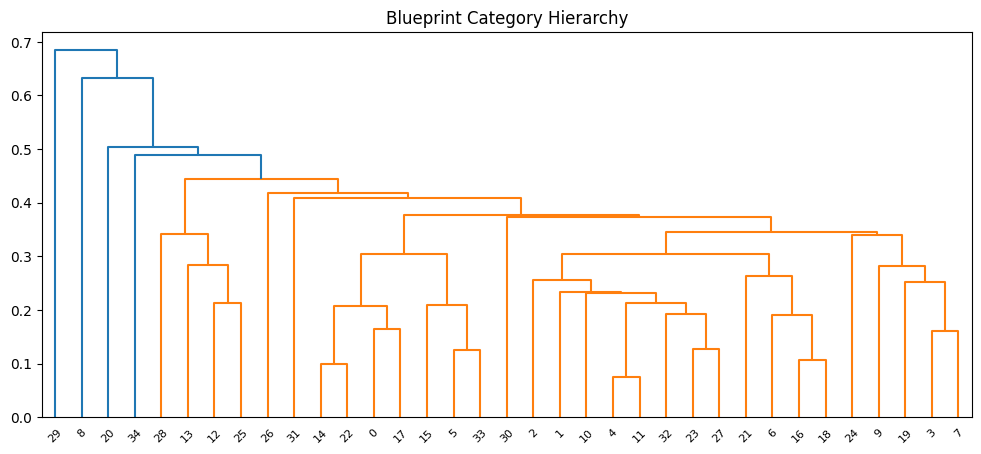

In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(centroids, method="average", metric="cosine")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Blueprint Category Hierarchy")
plt.show()

In [24]:
bp_df["top_cluster"].unique().shape

(10,)

In [29]:
def write_to_md(filename: str):    
    with open(filename, "w", encoding="utf-8") as f:
        for cluster_id in range(agg.n_clusters_):
            f.write(f"<details>\n")
            features = analyze_cluster_features(bp_df, cluster_id, top_n=5)
            f.write(f"<summary> Cluster {cluster_id} </summary>\n\n")
            f.write(f"Top 5 features: \n")
            for feature, count in features:
                f.write(f"- {feature}: {count} \n")
            f.write("\n")
            sub_clusters = bp_df[bp_df["top_cluster"] == cluster_id]["fine_cluster"].unique()
            f.write(f"Sub-clusters: {', '.join(map(str, sub_clusters))} \n\n")
            for sub_cluster in sub_clusters:
                bps = bp_df[(bp_df["top_cluster"] == cluster_id) & (bp_df["fine_cluster"] == sub_cluster)]
                f.write(f"### Sub-cluster {sub_cluster}\n\n")
                for idx, bp in bps.iterrows():
                    post_url = topics_df[topics_df["post_id"] == bp["post_id"]]["post_url"].values[0]
                    f.write(f"- {bp['name']}, [Link]({post_url}) \n")
                f.write("\n")
c_name = "agg_clusters"
write_to_md(f"output/{c_name}.md")